# Deklaracje

| Ex1 | Ex2 | Ex3 | Ex4 |
| --- | --- | --- | --- |
| ✅ | ✅  | ✅ | ✅  |

# Ex1


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

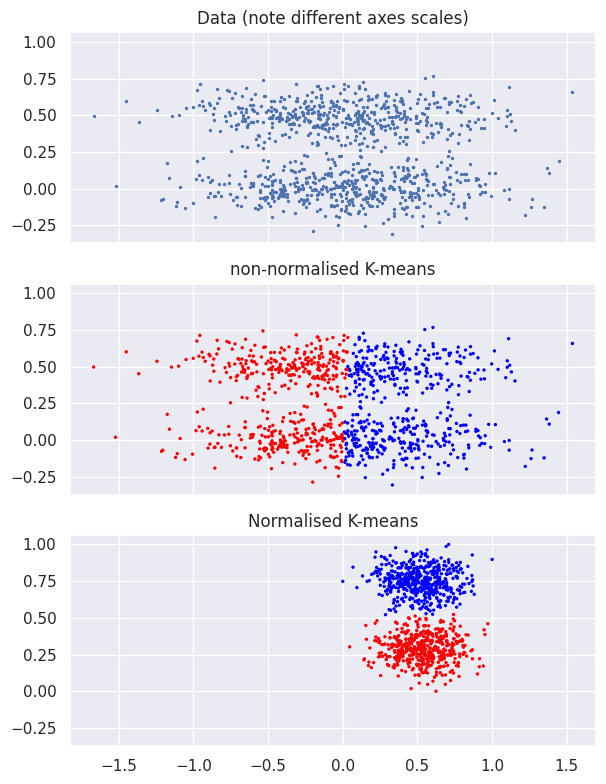

In [ ]:
import seaborn
from sklearn.cluster import KMeans

seaborn.set_theme()

rnorm = np.random.randn

x = rnorm(1000) / 2
y = np.concatenate([rnorm(500) + 5, rnorm(500)]) / 10

fig, axes = plt.subplots(3, 1, sharex=True, sharey=True, figsize=(6, 8))

axes[0].scatter(x, y, s=2)
axes[0].set_title("Data (note different axes scales)")

km = KMeans(2)
clusters = km.fit_predict(np.array([x, y]).T)

axes[1].scatter(x, y, c=clusters, cmap="bwr", s=2)
axes[1].set_title("non-normalised K-means")


def normalise(vals):
    """Normalise values to fit between [0, 1]"""
    return (vals - min(vals)) / (max(vals) - min(vals))


xn = normalise(x)
yn = normalise(y)

clusters = km.fit_predict(np.array([xn, yn]).T)

axes[2].scatter(xn, yn, c=clusters, cmap="bwr", s=2)
axes[2].set_title("Normalised K-means")

plt.tight_layout()

# Ex2

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [15]:
from pathlib import Path

imgs_dir = Path('ex2_imgs').iterdir()
imgs_paths = [p for p in imgs_dir]
imgs = [Image.open(p) for p in imgs_paths]

arrays = [np.array(img) for img in imgs]
f_arr, f2_arr, f3_arr = arrays

print(f_arr.shape, f2_arr.shape, f3_arr.shape)

(480, 640, 4) (480, 640, 4) (480, 640, 4)


In [16]:
def convertImgToCoords(img_array : np.ndarray) -> np.ndarray:
    img_rgb  = img_array[:, :, :3]
    img_gray = img_rgb.mean(axis=2)
    
    mask = img_gray < 250
    xs, ys = np.where(mask)
    
    img_coords = np.stack([xs, ys], axis=-1)
    return img_coords

f1_coords = convertImgToCoords(f_arr)
f2_coords = convertImgToCoords(f2_arr)
f3_coords = convertImgToCoords(f3_arr)

print(f1_coords.shape, f2_coords.shape, f3_coords.shape)

(8896, 2) (8893, 2) (9039, 2)


## Clustering

In [17]:
from sklearn.cluster import KMeans

def generate_range(start, end, step):
    return range(start, end + 1, step)

def eval_kmeans_for_n(n, f_coords : np.ndarray):
    kmeans = KMeans(n_clusters=n, n_init=2)
    labels = kmeans.fit_predict(f_coords)
    return labels, kmeans.inertia_, kmeans.cluster_centers_

def return_labels_for_range(cluster_range : range, f_coords : np.ndarray):
    labels_lst, interias, centers_lst = [], [], []
    for n in cluster_range:
        labels, inertia, centers = eval_kmeans_for_n(n, f_coords)
        labels_lst.append(labels)
        interias.append(inertia)
        centers_lst.append(centers)
    return labels_lst, interias, centers_lst  


start, end, step = 20, 300, 4
cluster_range = generate_range(start, end, step)

f1_labels_lst, f1_interias, f1_centers_lst = return_labels_for_range(cluster_range, f1_coords)
f2_labels_lst, f2_interias, f2_centers_lst = return_labels_for_range(cluster_range, f2_coords)
f3_labels_lst, f3_interias, f3_centers_lst = return_labels_for_range(cluster_range, f3_coords)
print(len(f1_labels_lst), len(f2_labels_lst), len(f3_labels_lst))

71 71 71


In [18]:
import ipywidgets

def plot_figure(idx, labels_lst, xs, ys, cluster_range):
    plt.figure(figsize=(8,8))
    plt.scatter(ys, -xs, s=0.05, c=labels_lst[idx], cmap='tab20')
    plt.title(f'K-means with n={cluster_range[idx]} clusters')

def interact_plot(labels_lst, xs, ys, cluster_range):
    ipywidgets.interact(plot_figure,
         idx=ipywidgets.IntSlider(value=0, min=0, max=len(labels_lst)-1, step=1),
         labels_lst=ipywidgets.fixed(labels_lst),
         xs=ipywidgets.fixed(xs),
         ys=ipywidgets.fixed(ys),
         cluster_range=ipywidgets.fixed(cluster_range))

In [ ]:
interact_plot(f1_labels_lst, f1_coords[:,0], f1_coords[:,1], cluster_range)
# best - 256

interactive(children=(IntSlider(value=0, description='idx', max=70), Output()), _dom_classes=('widget-interact…

In [ ]:
interact_plot(f2_labels_lst, f2_coords[:, 0], f2_coords[:, 1], cluster_range)
# best - 256

interactive(children=(IntSlider(value=0, description='idx', max=70), Output()), _dom_classes=('widget-interact…

In [21]:
interact_plot(f3_labels_lst, f3_coords[:,0], f3_coords[:,1], cluster_range)
#best - 224

interactive(children=(IntSlider(value=0, description='idx', max=70), Output()), _dom_classes=('widget-interact…

In [ ]:
f1_best_centers = f1_centers_lst[59]
f2_best_centers = f2_centers_lst[59]
f3_best_centers = f3_centers_lst[51]

In [113]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

def eval_dbscan(f_arr, eps=0.3, min_samples = 3):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    
    labels = dbscan.fit_predict(f_arr)
    return labels

def scale_eval(f_arr, eps=0.3, min_samples=3):
    scaler = StandardScaler()
    f_scaled = scaler.fit_transform(f_arr)
    labels = eval_dbscan(f_scaled, eps=eps, min_samples=min_samples)
    return f_scaled, labels

def plot_clustering_result(f_arr, labels):
    plt.scatter(f_arr[:, 1], -f_arr[:, 0], c=labels, cmap='tab20')
    

Text(0.5, 1.0, 'Agglomerative Clustering')

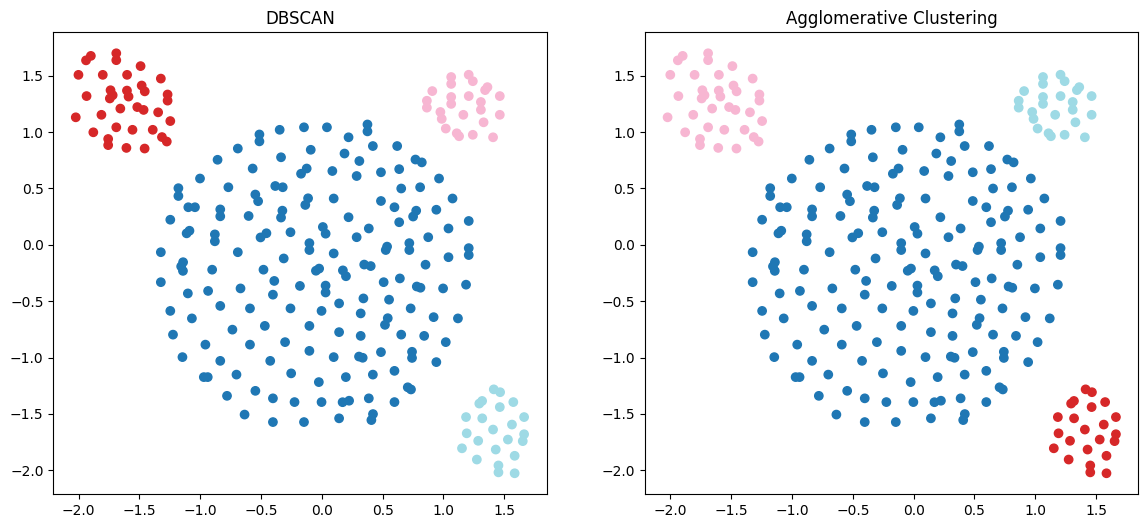

In [119]:
from sklearn.cluster import AgglomerativeClustering
def eval_agglomerative(f_arr, n_clusters=3, linkage='single'):
    agglomerative = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    labels = agglomerative.fit_predict(f_arr)
    return labels

plt.figure(figsize=(14,6))
plt.subplot(121)
f1_scaled, l1 = scale_eval(f1_best_centers, eps=0.3, min_samples=3)
plot_clustering_result(f1_scaled, l1)
plt.title("DBSCAN")

plt.subplot(122)
plot_clustering_result(f1_scaled, eval_agglomerative(f1_best_centers, n_clusters=4))
plt.title("Agglomerative Clustering")

Text(0.5, 1.0, 'Agglomerative Clustering')

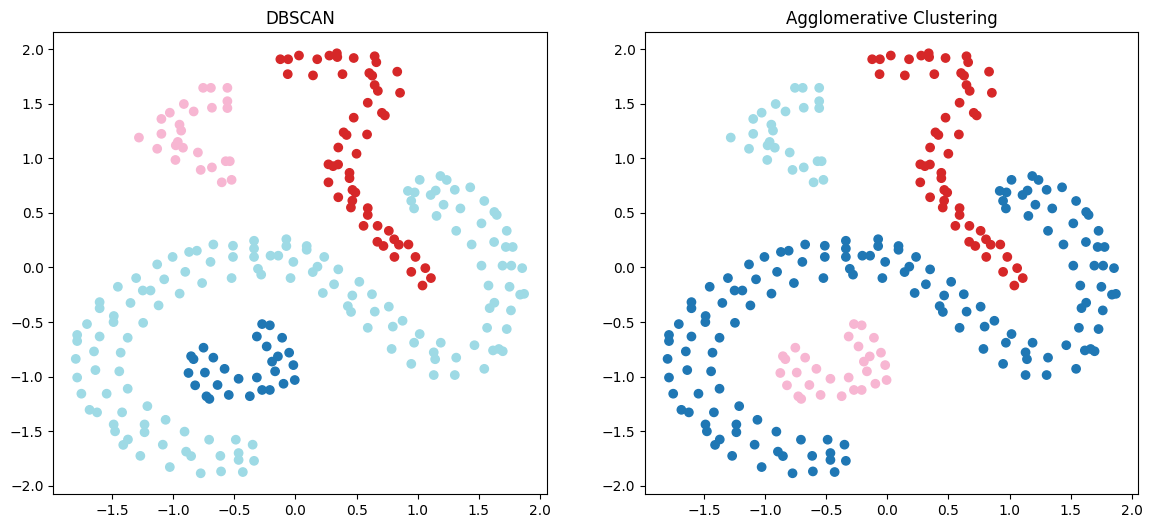

In [121]:
plt.figure(figsize=(14,6))
plt.subplot(121)
f2_scaled, l2 = scale_eval(f2_best_centers, eps=0.25, min_samples=5)
plot_clustering_result(f2_scaled, l2)
plt.title("DBSCAN")

plt.subplot(122)
plot_clustering_result(f2_scaled, eval_agglomerative(f2_best_centers, n_clusters=4))
plt.title("Agglomerative Clustering")

Text(0.5, 1.0, 'Agglomerative Clustering')

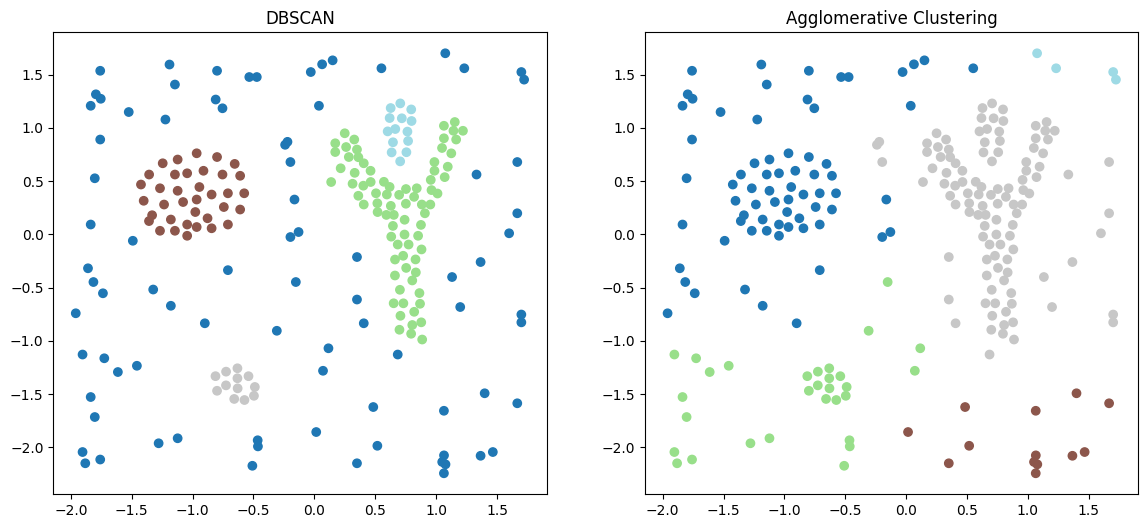

In [124]:
plt.figure(figsize=(14,6))
plt.subplot(121)
f3_scaled, l3 = scale_eval(f3_best_centers, eps=0.2, min_samples=5)
plot_clustering_result(f3_scaled, l3)
plt.title("DBSCAN")

plt.subplot(122)
plot_clustering_result(f3_scaled, eval_agglomerative(f3_best_centers, n_clusters=5, linkage='average'))
plt.title("Agglomerative Clustering")

# Ex 3

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
from PIL import Image

img_array = Image.open('ex3_imgs/golden-retriever.jpg')
img_array = np.array(img_array)
img_array.shape

(430, 710, 3)

In [45]:
pixels = img_array.reshape(-1, 3)
pixels.shape

(305300, 3)

In [46]:

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10)

result = kmeans.fit_predict(pixels)

In [47]:
print(kmeans.cluster_centers_)
clusters = kmeans.cluster_centers_

[[115.74205317 111.54606621  45.69570288]
 [247.64925256 236.19484658 216.26188041]
 [152.75145709 161.13445598  73.48272663]
 [ 44.35621762  31.7373057   15.66981865]
 [226.702342   198.01330931 160.82819221]
 [131.85950346 142.64313274  57.10744803]
 [200.43369565 159.25303708 119.91700767]
 [171.79093856 123.22579083  75.09691121]
 [ 83.8596484   83.29488349  26.5741355 ]
 [175.71627753 181.35933102  96.74661368]]


In [48]:
mapped_clusters = {l: c for l, c in enumerate(clusters)}

In [49]:
reduced = np.array([mapped_clusters[r] for r in result])
reduced.shape

(305300, 3)

In [50]:
reshaped_reduced = reduced.reshape(430, 710, 3)
reshaped_reduced.shape

(430, 710, 3)

In [63]:
new_img = Image.fromarray(reshaped_reduced.astype('uint8'))
new_img.show()

In [52]:
print(result.shape)

zeros = np.zeros((result.shape[0], 2))
print(zeros.shape)

x = result.reshape(-1, 1)
stacked_result = np.hstack([x, zeros])
stacked_result.shape

(305300,)
(305300, 2)


(305300, 3)

Text(0.5, 1.0, 'Reduced Colors Image')

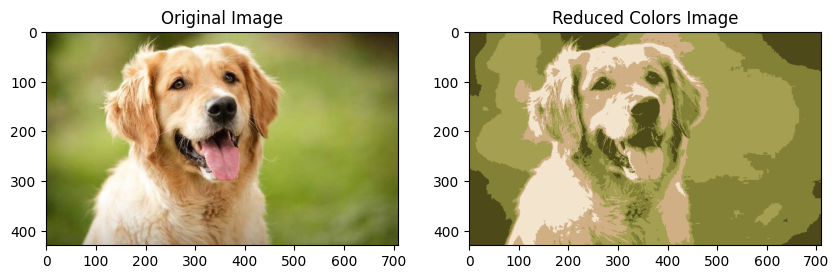

In [77]:
def map_labels_into_colors(labels, centers):
    mapped_clusters = {l: c for l, c in enumerate(centers)}
    return np.array([mapped_clusters[r] for r in labels])
    
def reduce_colors_in_img(img, colorsNo):
    img_array = np.array(img)
    og_img_shape = img_array.shape
    pixels = img_array.reshape(-1, 3)
    
    kmeans = KMeans(n_clusters=colorsNo, n_init=3)
    pred_labels = kmeans.fit_predict(pixels)
    
    mapped_labels = map_labels_into_colors(pred_labels, kmeans.cluster_centers_)
    color_reduced_img = mapped_labels.reshape(og_img_shape)
    return Image.fromarray(color_reduced_img.astype('uint8'))

plt.figure(figsize=(10,5))
img = Image.open('ex3_imgs/golden-retriever.jpg')
plt.subplot(121)
plt.imshow(img)
plt.title('Original Image')

plt.subplot(122)
red = reduce_colors_in_img(img, 5)
plt.imshow(red)
plt.title('Reduced Colors Image')

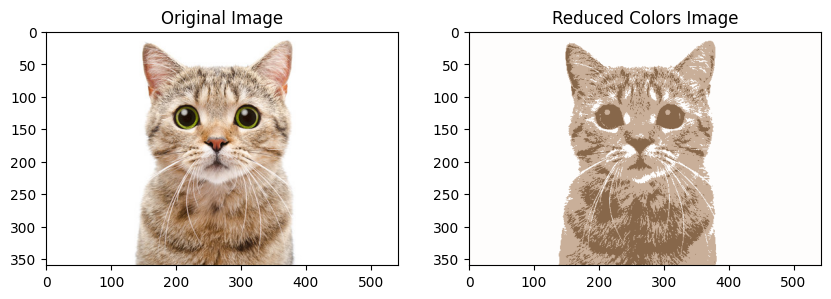

In [128]:
img1 = Image.open('ex3_imgs/cat_img.jpg')
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.title('Original Image')
plt.imshow(img1)

plt.subplot(122)
plt.title('Reduced Colors Image')
red = reduce_colors_in_img(img1, 3)
plt.imshow(red)

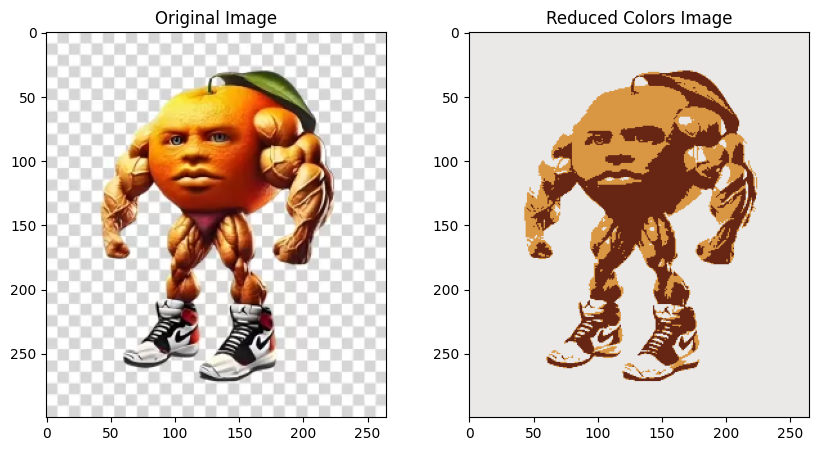

In [129]:
img2 = Image.open('ex3_imgs/Udin-Din-Din-Dun-Transparent-265x300.jpg')
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(img2)
plt.title('Original Image')

plt.subplot(122)
plt.title('Reduced Colors Image')
red = reduce_colors_in_img(img2, 3)
plt.imshow(red)

# Ex4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

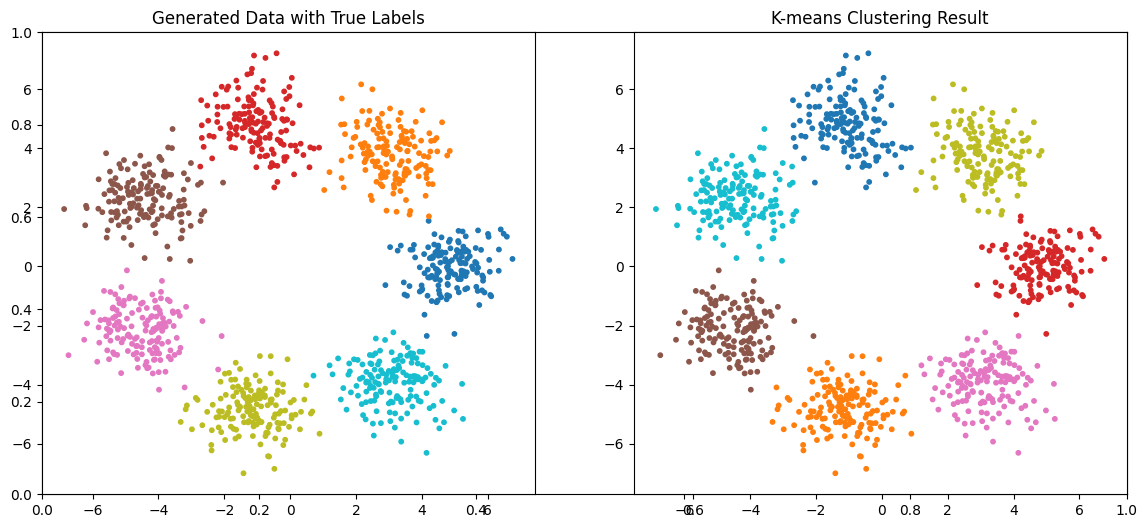

In [2]:
from sklearn.cluster import KMeans

def generate_polygonal_data(K=7, M=150, sigma=0.7, radius=6, model=KMeans):
    angles = np.linspace(0, 2 * np.pi, K, endpoint=False)
    verts = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

    all_points = []
    true_labels = []
    for i in range(K):
        pts = np.random.randn(M, 2) * sigma + verts[i]
        all_points.append(pts)
        true_labels.append(np.full(M, i))
        
    X = np.vstack(all_points)
    kmeans = model(n_clusters=K)
    pred_labels = kmeans.fit_predict(X)
    y_true = np.concatenate(true_labels)
    return X, y_true, pred_labels

X, y_true, labels = generate_polygonal_data(K=7, M=150, sigma=0.8, radius=5)

plt.subplots(figsize=(14,6))
plt.subplot(121)
plt.scatter(X[:,0], X[:,1], c=y_true, cmap='tab10', s=10)
plt.title('Generated Data with True Labels')
plt.subplot(122)
plt.scatter(X[:,0], X[:,1], c=labels, cmap='tab10', s=10)
plt.title('K-means Clustering Result')
plt.show()

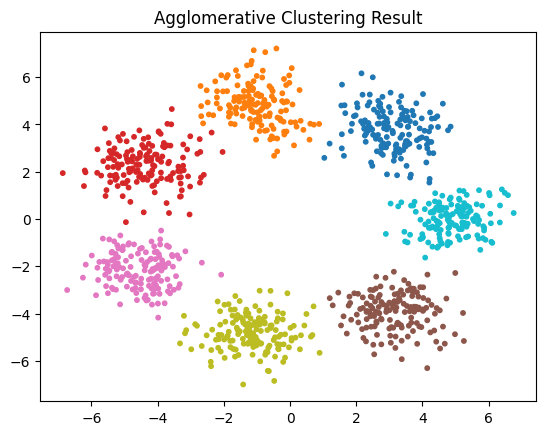

In [3]:
from sklearn.cluster import AgglomerativeClustering
agglo = AgglomerativeClustering(distance_threshold=15, n_clusters=None)
y_agglo = agglo.fit_predict(X)
plt.scatter(X[:,0], X[:,1], c=y_agglo, cmap='tab10', s=10)
plt.title('Agglomerative Clustering Result')
plt.show()

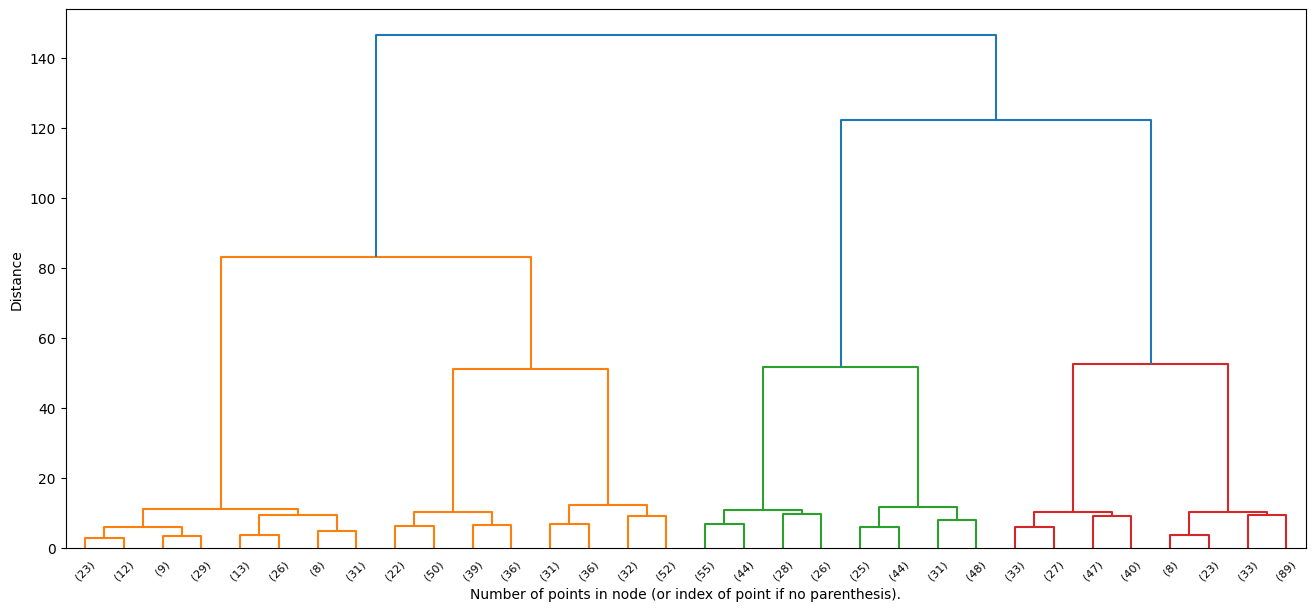

In [4]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

plt.figure(figsize=(16, 7))
plot_dendrogram(agglo, truncate_mode="level", p=4)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance")
plt.show()

<Figure size 1600x600 with 0 Axes>

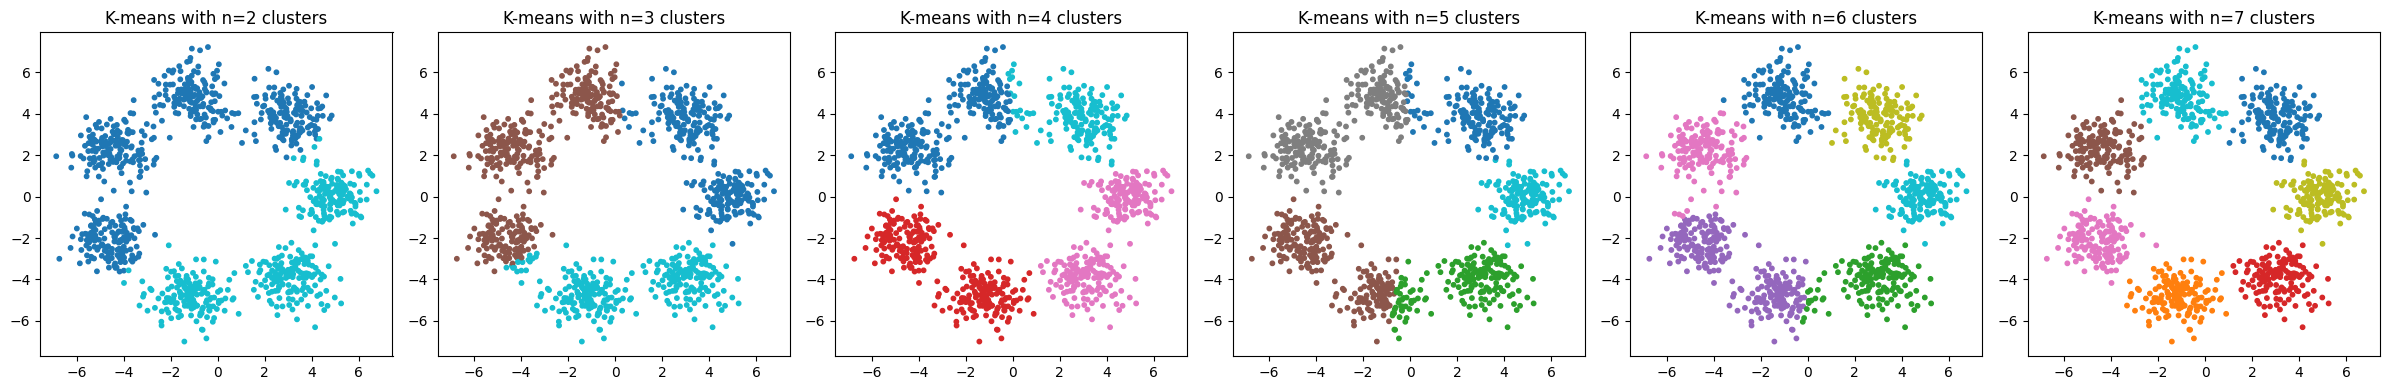

In [6]:
def eval_kmeans_for_n(n, f_coords : np.ndarray):
    kmeans = KMeans(n_clusters=n, n_init=2)
    labels = kmeans.fit_predict(f_coords)
    return labels, kmeans.cluster_centers_

def plot_subplots(labels, f_coords, n):
    plt.figure(figsize=(4 * len(labels), 4))
    for i in range(len(labels)):
        plt.subplot(1, len(labels), i + 1)
        plt.scatter(f_coords[:, 0], f_coords[:, 1], c=labels[i], cmap='tab10', s=10)
        plt.title(f'K-means with n={n[i]} clusters')
    plt.tight_layout()
 
K=7       
plt.figure(figsize=(16,6))
labels_lst = [l for l in [eval_kmeans_for_n(n, X)[0] for n in range(2, K+1)]]
plot_subplots(labels_lst, X, list(range(2, K+1)))

In [11]:
labels_kmeans.shape

(1000000,)

# symetralne w kmeans - przewidują jak się zachowa kmeans

In [13]:
import time
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score
K = 10**2
M = 10**4
sigma = 0.7
radius = 5

# KMeans
start = time.time()
X_kmeans, y_true_kmeans, labels_kmeans = generate_polygonal_data(K, M, sigma, radius)
kmeans_time = time.time() - start
kmeans_score = adjusted_rand_score(y_true_kmeans, labels_kmeans)

# MiniBatchKMeans
start = time.time()
X_mbkmeans, y_true_mbkmeans, labels_mbkmeans = generate_polygonal_data(K, M, sigma, radius, model=MiniBatchKMeans)
mbkmeans_time = time.time() - start
mbkmeans_score = adjusted_rand_score(y_true_mbkmeans, labels_mbkmeans)

print(f"KMeans:      time = {kmeans_time:.2f}s, ARI = {kmeans_score:.4f}")
print(f"MiniBatch:   time = {mbkmeans_time:.2f}s, ARI = {mbkmeans_score:.4f}")

KMeans:      time = 8.27s, ARI = 0.1120
MiniBatch:   time = 0.61s, ARI = 0.1121
